In [556]:
import numpy as np

import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset # Para manejar datasets
import matplotlib.pyplot as plt
# import datetime as dt

In [ ]:
import pandas as pd
df = pd.read_csv("Data/seattle-weather.csv")
# df['date'] = pd.to_datetime(df['date'], errors='coerce') 
# df = df.drop_duplicates(subset=['date']) # Eliminar filas con fechas duplicadas
# df = df.dropna(subset=['temp_max']) # Eliminar filas con valores NaN en la columna 'temp_max'
df

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain
...,...,...,...,...,...,...
1456,2015-12-27,8.6,4.4,1.7,2.9,rain
1457,2015-12-28,1.5,5.0,1.7,1.3,rain
1458,2015-12-29,0.0,7.2,0.6,2.6,fog
1459,2015-12-30,0.0,5.6,-1.0,3.4,sun


In [558]:

y = df['temp_max'].astype(float).values 
W = 3
def build_lag_matrix(y_array, window):
    X_lags = []
    for t in range(window, len(y_array)):
        X_lags.append(y_array[t-window:t][::-1])
    return np.array(X_lags)

X_lags = build_lag_matrix(y, W)
X = X_lags
y_target = y[W:]

In [559]:
#mostrar la matriz de lags
X



array([[11.7, 10.6, 12.8],
       [12.2, 11.7, 10.6],
       [ 8.9, 12.2, 11.7],
       ...,
       [ 5. ,  4.4,  4.4],
       [ 7.2,  5. ,  4.4],
       [ 5.6,  7.2,  5. ]], shape=(1458, 3))

# Division de Datos

In [560]:


N = len(y_target)
X_train, X_val = X[:int(N*0.8)], X[int(N*0.8):]
y_train, y_val = y_target[:int(N*0.8)], y_target[int(N*0.8):]

In [561]:
# from sklearn.model_selection import train_test_split

# # Split de datos (manteniendo el orden temporal)
# X_train, X_val, y_train, y_val = train_test_split(
#     X, y_target, test_size=0.2, shuffle=False
# )

# Normalizacion Manual

In [562]:

X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0) + 1e-8
X_train_norm = (X_train - X_mean) / X_std
X_val_norm = (X_val - X_mean) / X_std
y_mean = y_train.mean()
y_std = y_train.std() + 1e-8
y_train_norm = (y_train - y_mean) / y_std
y_val_norm = (y_val - y_mean) / y_std

# Normalizacion Sklearn

In [563]:
# from sklearn.preprocessing import StandardScaler

# # Normalizar X
# scaler_X = StandardScaler()
# X_train_norm = scaler_X.fit_transform(X_train)
# X_val_norm = scaler_X.transform(X_val)

# # Normalizar y
# scaler_y = StandardScaler()
# y_train_norm = scaler_y.fit_transform(y_train.reshape(-1, 1)).reshape(-1)
# y_val_norm = scaler_y.transform(y_val.reshape(-1, 1)).reshape(-1)

# Herramientas PyTorch

In [564]:

class TempDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.from_numpy(X).float()
        self.Y = torch.from_numpy(Y).float().view(-1, 1)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, ix):
        return self.X[ix], self.Y[ix]
    
    
dataset = {
    'train': TempDataset(X_train_norm, y_train_norm),
    'val': TempDataset(X_val_norm, y_val_norm)
}
dataloader = {
    'train': DataLoader(dataset['train'], batch_size=32, shuffle=True),
    'val': DataLoader(dataset['val'], batch_size=1000, shuffle=False)
}


# Model MLP

In [565]:

def build_model(D_in, H=64, D_out=1):
    return nn.Sequential(
        nn.Linear(D_in, H),
        nn.ReLU(),
        nn.Linear(H, H),
        nn.ReLU(),
        nn.Linear(H, D_out)
    )


In [566]:
model = build_model(X.shape[1])
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

# Entrenamiento

In [567]:

def fit(model, dataloader, epochs=100):
    l, val_l = [], []
    for e in range(1, epochs+1):
        model.train()
        batch_losses = []
        for x_b, y_b in dataloader['train']: # batch
            y_pred = model(x_b)
            loss = criterion(y_pred, y_b)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
        l.append(np.mean(batch_losses))
        model.eval()
        val_losses = []
        with torch.no_grad():
            for x_b, y_b in dataloader['val']:
                y_pred = model(x_b)
                loss = criterion(y_pred, y_b)
                val_losses.append(loss.item())
        val_l.append(np.mean(val_losses))
        if e % 10 == 0:
            print(f"Epoch {e} | loss {l[-1]:.3f} | val_loss {val_l[-1]:.3f}")
    return {'epoch': list(range(1, epochs+1)), 'loss': l, 'val_loss': val_l}

hist = fit(model, dataloader, epochs=100)

Epoch 10 | loss 0.222 | val_loss 0.265
Epoch 20 | loss 0.186 | val_loss 0.217
Epoch 30 | loss 0.176 | val_loss 0.206
Epoch 40 | loss 0.171 | val_loss 0.199
Epoch 50 | loss 0.164 | val_loss 0.192
Epoch 60 | loss 0.159 | val_loss 0.187
Epoch 70 | loss 0.155 | val_loss 0.183
Epoch 80 | loss 0.152 | val_loss 0.180
Epoch 90 | loss 0.151 | val_loss 0.178
Epoch 100 | loss 0.147 | val_loss 0.177


# Grafica de entrenamiento

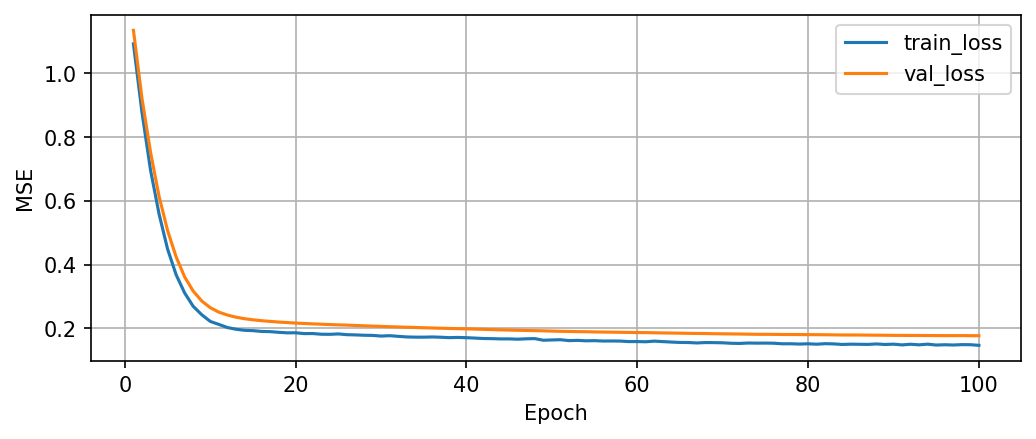

In [568]:

fig = plt.figure(dpi=150, figsize=(8,3))
plt.plot(hist['epoch'], hist['loss'], label='train_loss')
plt.plot(hist['epoch'], hist['val_loss'], label='val_loss')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.legend(); plt.grid()
plt.show()

In [569]:

model.eval()
y_val_pred_norm = []
with torch.no_grad():
    for x_b, _ in dataloader['val']:
        y_pred = model(x_b)
        y_val_pred_norm.append(y_pred.numpy().reshape(-1))
y_val_pred_norm = np.concatenate(y_val_pred_norm)
y_val_pred = y_val_pred_norm * y_std + y_mean

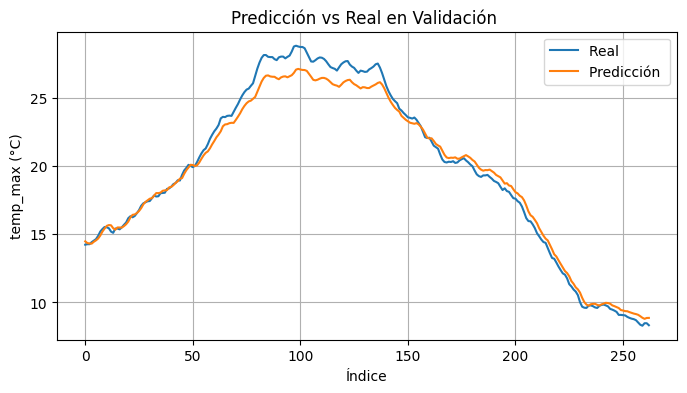

In [570]:

def moving_average(arr, window=30):
    return np.convolve(arr, np.ones(window)/window, mode='valid')

window = 30 # Puedes probar con 5, 7, 10...
y_val_smooth = moving_average(y_val, window)
y_val_pred_smooth = moving_average(y_val_pred, window)

plt.figure(figsize=(8,4))
plt.plot(y_val_smooth, label='Real ')
plt.plot(y_val_pred_smooth, label='Predicción ')
plt.title('Predicción vs Real en Validación ')
plt.xlabel('Índice'); plt.ylabel('temp_max (°C)')
plt.legend(); plt.grid()
plt.show()

In [571]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

model.eval()
y_val_pred_norm = []
with torch.no_grad():
    for x_b, _ in dataloader['val']:
        y_pred = model(x_b)
        y_val_pred_norm.append(y_pred.numpy().reshape(-1))
y_val_pred_norm = np.concatenate(y_val_pred_norm)
y_val_pred = y_val_pred_norm * y_std + y_mean 
mse = mean_squared_error(y_val, y_val_pred)
mae = mean_absolute_error(y_val, y_val_pred)
r2 = r2_score(y_val, y_val_pred)

print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2: {r2:.3f}")

MSE: 9.22
MAE: 2.41
R2: 0.832


In [572]:
dias_a_predecir = 30
ultimos_lags = y[-W:]  
predicciones = []

for i in range(dias_a_predecir):
    lags_norm = (ultimos_lags - X_mean) / X_std
    lags_tensor = torch.from_numpy(lags_norm.reshape(1, -1)).float()
    with torch.no_grad():
        pred_norm = model(lags_tensor).item()
    pred_real = pred_norm * y_std + y_mean
    predicciones.append(pred_real)
    ultimos_lags = np.append(ultimos_lags[1:], pred_real)

print("Predicciones para los próximos 30 días:")
print(predicciones)

Predicciones para los próximos 30 días:
[np.float64(7.434480242601232), np.float64(6.808962275509973), np.float64(6.851882684176532), np.float64(7.828371658735286), np.float64(7.635758421622244), np.float64(7.7003837656826235), np.float64(8.237633389771716), np.float64(8.221867376142281), np.float64(8.29147938437823), np.float64(8.601364820972247), np.float64(8.6428538325044), np.float64(8.714250786085234), np.float64(8.896309189761284), np.float64(8.95137324827544), np.float64(9.013511711857713), np.float64(9.125017892713739), np.float64(9.17634173804256), np.float64(9.228013110079495), np.float64(9.299998450463175), np.float64(9.34272703126857), np.float64(9.38360012912991), np.float64(9.432097309204131), np.float64(9.465850410622279), np.float64(9.497012545592813), np.float64(9.53033812034281), np.float64(9.555778967848843), np.float64(9.579004762697966), np.float64(9.602354428452955), np.float64(9.621275709323374), np.float64(9.63843785128763)]


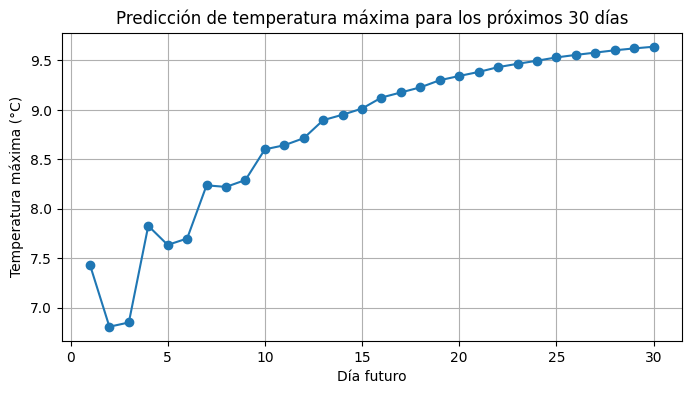

In [573]:

plt.figure(figsize=(8,4))
plt.plot(range(1, dias_a_predecir+1), predicciones, marker='o')
plt.title('Predicción de temperatura máxima para los próximos 30 días')
plt.xlabel('Día futuro')
plt.ylabel('Temperatura máxima (°C)')
plt.grid()
plt.show()